# Mg–H Phase Diagram

This notebook builds an illustrative Mg–H phase diagram from ASE thermochemistry
primitives wrapped as landau `AsePhase` objects.  The composition axis is the
hydrogen atomic fraction $c = N_\mathrm{H} / (N_\mathrm{H} + N_\mathrm{Mg})$, so
$c = 0$ is pure Mg, $c = 2/3$ is stoichiometric MgH$_2$, and $c = 1$ is pure H.

Phases included:

| Phase | Type | Description |
|-------|------|-------------|
| `Mg(s, H)` | `SlowInterpolatingPhase` | Mg-rich solid solution with limited H solubility |
| `Mg(l)`    | `AsePhase` (`HarmonicThermo`) | Mg liquid line phase at $c = 0$ |
| `gas`      | `IdealSolution` of two `AsePhase`s | Mixture of monatomic Mg vapour and H$_2$ |
| `MgH2`     | `AsePhase` (`HarmonicThermo`) | Stoichiometric solid hydride at $c = 2/3$ |

**This notebook is for illustration only.**  The numerical parameters below are picked
to roughly recover three reference points — the Mg melting temperature (923 K), the
Mg boiling temperature (1363 K), and a MgH$_2$ decomposition temperature near 690 K
at 1 atm H$_2$ — and are not transferable.  The MgH$_2$ static energy is taken from
Materials Project entry [mp-23710](https://next-gen.materialsproject.org/materials/mp-23710);
all vibrational and gas-phase parameters are hand-tuned, not derived.  Use this
notebook as a template for the workflow, not as a quantitative reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ase.atoms import Atoms
from ase.build import molecule
from ase.thermochemistry import HarmonicThermo, IdealGasThermo

from landau.phases.asewrapper import AsePhase
from landau.phases import SlowInterpolatingPhase, IdealSolution
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram

p_ref = 101325.0  # 1 atm reference pressure for gas phases

## Magnesium phases

Three Mg phases at $c = 0$ — solid, liquid, gas — each with a single static energy and
an effective vibrational/translational free energy:

* **Solid Mg** — three Einstein modes near the Debye energy ($\theta_D \approx 330$ K,
  $E_D \approx 28$ meV); reference energy $E_0 = 0$.
* **Liquid Mg** — softer Einstein modes (more vibrational entropy) and a static energy
  raised by an effective latent heat of fusion.  The static-energy shift is tuned so
  that $F_\mathrm{s}(T) = F_\mathrm{l}(T)$ at $T \approx 923$ K.
* **Gas Mg** — monatomic ideal gas via `IdealGasThermo`; the static energy is tuned so
  that $F_\mathrm{l}(T) = G_\mathrm{g}(T, 1\,\mathrm{atm})$ at $T \approx 1363$ K.

In [2]:
mg_solid_thermo = HarmonicThermo(
    vib_energies=[0.028] * 3,
    potentialenergy=0.0,
)

mg_liquid_thermo = HarmonicThermo(
    vib_energies=[0.019] * 3,
    potentialenergy=0.0932,
)
mg_liquid = AsePhase(name='Mg(l)', fixed_concentration=0.0, thermochem=mg_liquid_thermo)

mg_atom = Atoms('Mg', positions=[[0.0, 0.0, 0.0]], masses=[24.305])
mg_gas_thermo = IdealGasThermo(
    vib_energies=[], geometry='monatomic', atoms=mg_atom,
    symmetrynumber=1, spin=0, potentialenergy=1.7027,
)
mg_gas = AsePhase(name='Mg(g)', fixed_concentration=0.0, thermochem=mg_gas_thermo, pressure=p_ref)

## Solid Mg with dilute H solubility

Hydrogen has a small but finite solubility in solid Mg (positive heat of solution).
We represent this with a `SlowInterpolatingPhase` between two `AsePhase` endpoints:

* pure Mg ($c = 0$, the same `HarmonicThermo` as above), and
* a saturated Mg–H reference at $c = 0.05$ with a slightly elevated static energy and
  one stiffer (H-like) mode per atom.

Adding the ideal mixing entropy on top (`add_entropy=True`) yields a phase whose
equilibrium $c$ stays small at low $T$ and grows with $\mu_\mathrm{H}$.

In [3]:
mg_pure = AsePhase(name='Mg(s)', fixed_concentration=0.0, thermochem=mg_solid_thermo)

mg_h_thermo = HarmonicThermo(
    vib_energies=[0.028, 0.028, 0.040],
    potentialenergy=0.010,
)
mg_h = AsePhase(name='Mg-H sat.', fixed_concentration=0.05, thermochem=mg_h_thermo)

mg_solid = SlowInterpolatingPhase(
    name='Mg(s, H)',
    phases=[mg_pure, mg_h],
    add_entropy=True,
)

## Hydride and gas phases

**MgH$_2$** is a stoichiometric line phase at $c = 2/3$.  The static energy per atom
is taken from Materials Project entry
[mp-23710](https://next-gen.materialsproject.org/materials/mp-23710): $\Delta H_f \approx
-0.27$ eV/atom relative to elemental Mg(s) and H$_2$(g) standard states.  The
vibrational mode energy is tuned so that
$G_\mathrm{MgH_2}(T) = G_\mathrm{Mg(s)}(T) + \tfrac{1}{2} G_\mathrm{H_2(g)}(T, 1\,\mathrm{atm})$
at $T \approx 690$ K, the Materials Project-predicted MgH$_2$ melting/decomposition
temperature ([hydride contributions database](https://next-gen.materialsproject.org/contribs/contributions/65cfa8cd1db79045ca68a428)).

**Gas mixture** is an `IdealSolution` of monatomic Mg vapour ($c = 0$) and molecular
H$_2$ ($c = 1$).  H$_2$ contributes two atoms per molecule, so its `AsePhase` uses
`atoms_per_formula=2` to convert ASE's per-molecule Gibbs energy to a per-atom value
(landau's convention).

In [4]:
mgh2_thermo = HarmonicThermo(
    vib_energies=[0.0627] * 3,
    potentialenergy=-0.27,
)
mgh2 = AsePhase(name='MgH2', fixed_concentration=2/3, thermochem=mgh2_thermo)

h2_thermo = IdealGasThermo(
    vib_energies=[0.546], geometry='linear', atoms=molecule('H2'),
    symmetrynumber=2, spin=0, potentialenergy=0.0,
)
h2_gas = AsePhase(name='H2(g)', fixed_concentration=1.0,
                  thermochem=h2_thermo, pressure=p_ref, atoms_per_formula=2)

gas = IdealSolution(name='gas', phase1=mg_gas, phase2=h2_gas)

## Sanity check: calibration temperatures

Locate the three transitions used to fix the free parameters by running
`calc_phase_diagram` on the relevant pairs/triples of phases and reading the refined
`border` rows.

In [5]:
# Mg(s) ↔ Mg(l) and Mg(l) ↔ Mg(g) are pure-Mg transitions, so a 1D scan at a fixed
# (Mg-rich) mu suffices; the mu value is irrelevant for c=0 line phases.
T_cal = np.linspace(600, 1500, 60)
df_pure = calc_phase_diagram([mg_pure, mg_liquid, mg_gas],
                             Ts=T_cal, mu=-0.6, refine=True)
border_pure = df_pure.query('border')
T_melt = border_pure[border_pure['phase'] == 'Mg(l)']['T'].min()
T_boil = border_pure[border_pure['phase'] == 'Mg(g)']['T'].min()

# MgH2 decomposition is the upper edge of MgH2 stability in the (T, mu) plane.
df_dec = calc_phase_diagram([mg_pure, mgh2, h2_gas],
                            Ts=np.linspace(300, 1000, 50),
                            mu=np.linspace(-0.5, 0.0, 80), refine=True)
T_dec = df_dec.query('phase == "MgH2" and stable')['T'].max()

print(f'Mg melting          : {T_melt:.0f} K   (target 923 K)')
print(f'Mg boiling at 1 atm : {T_boil:.0f} K   (target 1363 K)')
print(f'MgH2 decomp at 1 atm: {T_dec:.0f} K   (target ≈ 690 K)')

Mg melting          : 923 K   (target 923 K)
Mg boiling at 1 atm : 1363 K   (target 1363 K)
MgH2 decomp at 1 atm: 690 K   (target ≈ 690 K)


## Phase diagram

We sweep $T$ from below the MgH$_2$ decomposition temperature to well above the Mg
boiling temperature, and $\Delta\mu = \mu_\mathrm{H} - \mu_\mathrm{Mg}$ across a range
wide enough to expose every phase region from Mg-rich to H-rich.

/home/user/landau/landau/poly.py:69: UserWarning: SegmentFastTsp._make produced an invalid polygon (Self-intersection[0.978163290923836 -1.44401024217564]); plotting will buffer it but the result may be inaccurate.
  warn(f"{type(self).__name__}._make produced an invalid polygon "


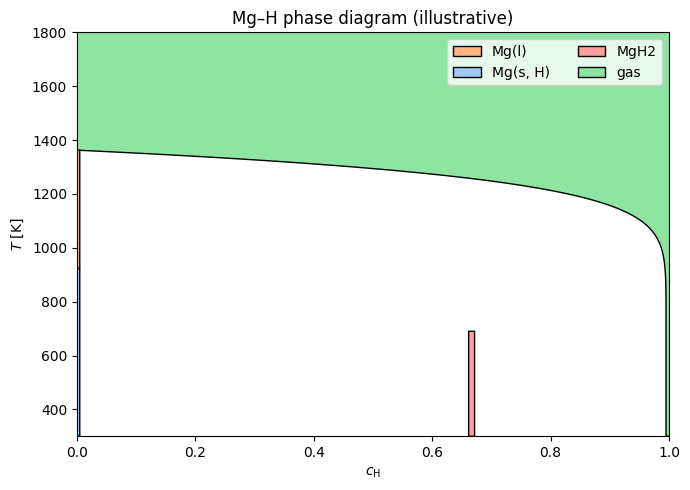

In [6]:
phases = [mg_solid, mg_liquid, gas, mgh2]
Ts = np.linspace(300, 1800, 150)
mu = np.linspace(-1.5, 0.5, 400)
df = calc_phase_diagram(phases, Ts=Ts, mu=mu, refine=True)

fig, ax = plt.subplots(figsize=(7, 5))
plot_phase_diagram(df, ax=ax, tielines=True)
ax.set_xlabel(r'$c_\mathrm{H}$')
ax.set_title('Mg–H phase diagram (illustrative)')
plt.tight_layout()
